# Adding the Delphi into the model

---

## Preparing libaries and packages

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import statsmodels.api as sm
from IPython.display import display
from sklearn.metrics import accuracy_score, roc_auc_score

# Locate and reopen the KGB in-sample dataset.
relative_path = Path("data") / "KGB Modelling" / "KGB in sample.csv"

data_path = next(
    (
        folder / relative_path
        for folder in [Path.cwd(), *Path.cwd().parents]
        if (folder / relative_path).is_file()
    ),
    None,
)

if data_path is None:
    raise FileNotFoundError(f"Could not locate {relative_path}")

kgb_with_delphi = pd.read_csv(data_path)
print(f"Loaded: {data_path}")

Loaded: c:\Users\georg\OneDrive\Coding\Origination-Scorecard\data\KGB Modelling\KGB in sample.csv


## Fitting the regression

In [7]:
selected_path = data_path.parent / "selected_model_data.csv"

if not selected_path.is_file():
    raise FileNotFoundError(
        f"Selected model data was not found: {selected_path}"
    )

previous_model = pd.read_csv(
    selected_path,
    index_col="row_index",
)

y_plus_delphi = previous_model["target_bad"].astype(int)

# Retain the selected predictors and create an explicit intercept.
X_plus_delphi = previous_model.drop(
    columns=["target_bad", "const"],
    errors="ignore",
).copy()
X_plus_delphi.insert(0, "const", 1.0)

# Confirm that the saved rows match the reopened in-sample dataset.
if not np.array_equal(
    kgb_with_delphi.loc[
        X_plus_delphi.index, "target_bad"
    ].to_numpy(),
    y_plus_delphi.to_numpy(),
):
    raise ValueError(
        "The saved model rows do not match the KGB in-sample file."
    )

delphi = pd.to_numeric(
    kgb_with_delphi.loc[
        X_plus_delphi.index, "DelphiScore"
    ],
    errors="coerce",
)

valid_rows = delphi.notna() & np.isfinite(delphi)
X_plus_delphi = X_plus_delphi.loc[valid_rows].copy()
y_plus_delphi = y_plus_delphi.loc[valid_rows]
delphi = delphi.loc[valid_rows]

if y_plus_delphi.nunique() != 2:
    raise ValueError("Both target classes must be present.")

delphi_std = delphi.std(ddof=0)
if not np.isfinite(delphi_std) or delphi_std == 0:
    raise ValueError("DelphiScore must vary across observations.")

X_plus_delphi["DelphiScore"] = (
    delphi - delphi.mean()
) / delphi_std

if np.linalg.matrix_rank(
    X_plus_delphi.to_numpy(dtype=float)
) < X_plus_delphi.shape[1]:
    raise ValueError(
        "The regression matrix has perfect multicollinearity."
    )

delphi_model = sm.Logit(
    y_plus_delphi,
    X_plus_delphi,
).fit(method="newton", maxiter=200, disp=False)

if not delphi_model.mle_retvals.get("converged", False):
    raise RuntimeError("The model with DelphiScore did not converge.")

# Dislaying the results

In [8]:
predicted_probability = delphi_model.predict(X_plus_delphi)
predicted_class = (predicted_probability >= 0.50).astype(int)

auc = roc_auc_score(y_plus_delphi, predicted_probability)
gini = 2 * auc - 1

coefficients = pd.DataFrame({
    "variable": delphi_model.params.index,
    "coefficient": delphi_model.params.values,
    "p_value": delphi_model.pvalues.values,
})

metrics = pd.Series({
    "Observations": int(delphi_model.nobs),
    "ROC AUC": auc,
    "Gini": gini,
    "AIC": delphi_model.aic,
    "McFadden pseudo R²": delphi_model.prsquared,
    "Log likelihood (LL)": delphi_model.llf,
    "Accuracy at 0.50 threshold": accuracy_score(
        y_plus_delphi, predicted_class
    ),
    "Converged": bool(delphi_model.mle_retvals["converged"]),
})

print("MODEL: PREVIOUSLY SELECTED VARIABLES + DELPHI")
display(coefficients)
display(metrics.to_frame("value"))
print(delphi_model.summary())

MODEL: PREVIOUSLY SELECTED VARIABLES + DELPHI


,variable,coefficient,p_value
0,const,-3.207363,0.000000e+00
1,committed_monthly_outgoings,-0.211648,1.665553e-02
2,debt_to_income_ratio,0.346002,9.117031e-07
3,recent_application_count,0.163984,6.589756e-03
4,revolving_utilisation,0.182453,1.362655e-02
5,historic_defaults,0.181789,2.143713e-03
6,loan_purpose=education,-1.036087,2.283667e-02
7,DelphiScore,0.018063,8.330270e-01


,value
Observations,7258
ROC AUC,0.626293
Gini,0.252586
AIC,2417.008427
McFadden pseudo R²,0.024464
Log likelihood (LL),-1200.504214
Accuracy at 0.50 threshold,0.959493
Converged,True


                           Logit Regression Results                           
Dep. Variable:             target_bad   No. Observations:                 7258
Model:                          Logit   Df Residuals:                     7250
Method:                           MLE   Df Model:                            7
Date:                Thu, 24 Sep 2026   Pseudo R-squ.:                 0.02446
Time:                        18:09:40   Log-Likelihood:                -1200.5
converged:                       True   LL-Null:                       -1230.6
Covariance Type:            nonrobust   LLR p-value:                 1.370e-10
                                  coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------------
const                          -3.2074      0.064    -50.353      0.000      -3.332      -3.083
committed_monthly_outgoings    -0.2116      0.088     -2.394      0.017      -0.

---

# Out-sample testing

In [9]:
from pathlib import Path

import numpy as np
import pandas as pd
import statsmodels.api as sm
from IPython.display import display
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)

# Locate both datasets.
relative_dir = Path("data") / "KGB Modelling"
project_root = next(
    (
        folder
        for folder in [Path.cwd(), *Path.cwd().parents]
        if (folder / relative_dir / "KGB in sample.csv").is_file()
    ),
    None,
)

if project_root is None:
    raise FileNotFoundError("Could not locate the KGB Modelling folder.")

in_sample = pd.read_csv(
    project_root / relative_dir / "KGB in sample.csv"
)
out_sample = pd.read_csv(
    project_root / relative_dir / "KGB out sample.csv"
)

# Predictors retained by the reduced model in notebook 09.
numeric_predictors = [
    "debt_to_income_ratio",
    "historic_defaults",
    "revolving_utilisation",
    "recent_application_count",
    "committed_monthly_outgoings",
]
required_columns = [
    "target_bad",
    "loan_purpose",
    *numeric_predictors,
]

def prepare_rows(data):
    rows = data[required_columns].copy()
    rows = rows.replace(r"^\s*$", np.nan, regex=True)
    rows = rows.replace([np.inf, -np.inf], np.nan)

    for column in ["target_bad", *numeric_predictors]:
        rows[column] = pd.to_numeric(
            rows[column], errors="coerce"
        )

    rows = rows.dropna().copy()
    if not rows["target_bad"].isin([0, 1]).all():
        raise ValueError("target_bad must contain only 0 and 1.")
    return rows

train = prepare_rows(in_sample)
test = prepare_rows(out_sample)

# Learn scaling from the in-sample data only.
train_means = train[numeric_predictors].mean()
train_stds = train[numeric_predictors].std(ddof=0)

if (train_stds == 0).any():
    raise ValueError("A numerical predictor has no variation.")

def make_design_matrix(rows):
    design = pd.DataFrame(
        {"const": 1.0},
        index=rows.index,
    )

    for column in numeric_predictors:
        design[column] = (
            rows[column] - train_means[column]
        ) / train_stds[column]

    design["loan_purpose=education"] = (
        rows["loan_purpose"] == "education"
    ).astype(float)

    return design

X_train = make_design_matrix(train)
X_test = make_design_matrix(test)
y_train = train["target_bad"].astype(int)
y_test = test["target_bad"].astype(int)

if y_train.nunique() != 2 or y_test.nunique() != 2:
    raise ValueError(
        "Both target classes must be present in each sample."
    )

# Fit on in-sample observations only. Do not select variables again.
reduced_model = sm.Logit(y_train, X_train).fit(
    method="newton",
    maxiter=200,
    disp=False,
)

if not reduced_model.mle_retvals.get("converged", False):
    raise RuntimeError("The reduced model did not converge.")

train_pd = reduced_model.predict(X_train)
test_pd = reduced_model.predict(X_test)

def performance(actual, probability):
    predicted_class = (probability >= 0.50).astype(int)
    auc = roc_auc_score(actual, probability)

    return {
        "Observations": len(actual),
        "Bad rate": actual.mean(),
        "ROC AUC": auc,
        "Gini": 2 * auc - 1,
        "Accuracy": accuracy_score(actual, predicted_class),
        "Precision": precision_score(
            actual, predicted_class, zero_division=0
        ),
        "Recall": recall_score(
            actual, predicted_class, zero_division=0
        ),
        "F1": f1_score(
            actual, predicted_class, zero_division=0
        ),
    }

comparison = pd.DataFrame({
    "In-sample": performance(y_train, train_pd),
    "Out-of-sample": performance(y_test, test_pd),
})

print("REDUCED MODEL — NO DELPHI SCORE")
display(comparison)

out_predictions = (test_pd >= 0.50).astype(int)
confusion = pd.DataFrame(
    confusion_matrix(y_test, out_predictions, labels=[0, 1]),
    index=["Actual good (0)", "Actual bad (1)"],
    columns=["Predicted good (0)", "Predicted bad (1)"],
)

print("\nOUT-OF-SAMPLE CONFUSION MATRIX")
display(confusion)

REDUCED MODEL — NO DELPHI SCORE


,In-sample,Out-of-sample
Observations,7258.000000,2458.000000
Bad rate,0.040507,0.041497
ROC AUC,0.625908,0.621554
Gini,0.251817,0.243109
Accuracy,0.959493,0.958503
Precision,0.000000,0.000000
Recall,0.000000,0.000000
F1,0.000000,0.000000



OUT-OF-SAMPLE CONFUSION MATRIX


,Predicted good (0),Predicted bad (1)
Actual good (0),2356,0
Actual bad (1),102,0


---

# Calibration check

OUT-OF-SAMPLE CALIBRATION BY RISK BAND


,risk_band,accounts,actual_bads,average_predicted_pd,actual_bad_rate,lowest_predicted_pd,highest_predicted_pd,difference
0,1,246,4,1.80%,1.63%,0.73%,2.42%,-0.17%
1,2,246,5,2.61%,2.03%,2.42%,2.77%,-0.58%
2,3,246,8,2.92%,3.25%,2.77%,3.04%,+0.34%
3,4,245,8,3.17%,3.27%,3.05%,3.32%,+0.09%
4,5,246,11,3.45%,4.47%,3.32%,3.58%,+1.02%
5,6,246,8,3.75%,3.25%,3.58%,3.91%,-0.50%
6,7,245,15,4.11%,6.12%,3.92%,4.36%,+2.01%
7,8,246,9,4.62%,3.66%,4.36%,4.90%,-0.97%
8,9,246,13,5.34%,5.28%,4.90%,5.93%,-0.05%
9,10,246,21,7.89%,8.54%,5.94%,33.35%,+0.65%


Overall average predicted PD: 3.97%
Overall actual bad rate: 4.15%


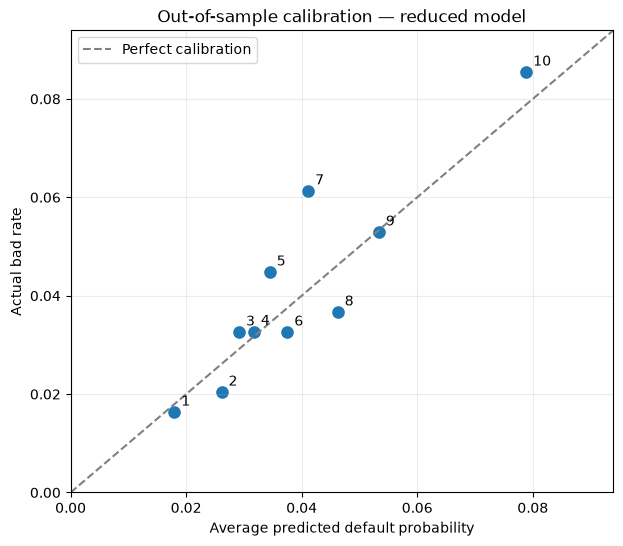

In [12]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

calibration_data = pd.DataFrame({
    "predicted_pd": np.asarray(test_pd, dtype=float),
    "actual_bad": np.asarray(y_test, dtype=int),
})

if not np.isfinite(calibration_data["predicted_pd"]).all():
    raise ValueError("Predicted probabilities contain invalid values.")

# Divide accounts into ten groups by predicted default probability.
calibration_data["band"] = pd.qcut(
    calibration_data["predicted_pd"],
    q=10,
    duplicates="drop",
)

calibration_table = (
    calibration_data
    .groupby("band", observed=True)
    .agg(
        accounts=("actual_bad", "size"),
        actual_bads=("actual_bad", "sum"),
        average_predicted_pd=("predicted_pd", "mean"),
        actual_bad_rate=("actual_bad", "mean"),
        lowest_predicted_pd=("predicted_pd", "min"),
        highest_predicted_pd=("predicted_pd", "max"),
    )
    .reset_index(drop=True)
)

calibration_table.insert(
    0, "risk_band", range(1, len(calibration_table) + 1)
)
calibration_table["difference"] = (
    calibration_table["actual_bad_rate"]
    - calibration_table["average_predicted_pd"]
)

print("OUT-OF-SAMPLE CALIBRATION BY RISK BAND")
display(
    calibration_table.style.format({
        "average_predicted_pd": "{:.2%}",
        "actual_bad_rate": "{:.2%}",
        "lowest_predicted_pd": "{:.2%}",
        "highest_predicted_pd": "{:.2%}",
        "difference": "{:+.2%}",
    })
)

print(
    f"Overall average predicted PD: "
    f"{calibration_data['predicted_pd'].mean():.2%}"
)
print(
    f"Overall actual bad rate: "
    f"{calibration_data['actual_bad'].mean():.2%}"
)

# Plot observed versus predicted bad rates.
fig, ax = plt.subplots(figsize=(7, 6))

ax.scatter(
    calibration_table["average_predicted_pd"],
    calibration_table["actual_bad_rate"],
    s=65,
)

for row in calibration_table.itertuples():
    ax.annotate(
        str(row.risk_band),
        (row.average_predicted_pd, row.actual_bad_rate),
        xytext=(5, 5),
        textcoords="offset points",
    )

upper_limit = max(
    calibration_table["average_predicted_pd"].max(),
    calibration_table["actual_bad_rate"].max(),
) * 1.1

ax.plot(
    [0, upper_limit],
    [0, upper_limit],
    linestyle="--",
    color="grey",
    label="Perfect calibration",
)

ax.set_xlim(0, upper_limit)
ax.set_ylim(0, upper_limit)
ax.set_xlabel("Average predicted default probability")
ax.set_ylabel("Actual bad rate")
ax.set_title("Out-of-sample calibration — reduced model")
ax.legend()
ax.grid(alpha=0.25)

plt.show()